In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import brentq
from scipy import integrate

#### Bathtub-shaped Hazard Rate 
Let $Z_1$ and $Z_2$ be independent Weibull random variables with shape parameters $k_1<1$ and $k_2>1$, and scale parameters $\beta_1>0$ and $\beta_2>0$, respectively. That is,
$$
\mathbb{P}(Z_i>t)= e^{-\left(\frac{t}{\beta_i }\right)^{k_i}  }, \quad t\geq 0, \quad i=1,2. 
$$


Define $X_1 = Z_1 \wedge Z_2$. Then its survival function and expectation are
$$
\overline{F}(t) = e^{-\left(\frac{t}{\beta_1}\right)^{k_1} - \left( \frac{t}{\beta_2}\right)^{k_2} }, \quad t\geq 0 \qquad \text{ and } \qquad a= \displaystyle\int_0^\infty e^{-\left(\frac{t}{\beta_1}\right)^{k_1} - \left( \frac{t}{\beta_2}\right)^{k_2} } \,\mathrm{d} t.
$$

The hazard rate of $X_1$ is given by
$$
r(t) = \frac{k_1}{\beta_1} \left(\frac{t}{\beta_1}\right)^{k_1 - 1} + \frac{k_2}{\beta_2} \left(\frac{t}{\beta_2 } \right)^{k_2 - 1}, \qquad t\geq0, 
$$
and it is well known that $r(t)$ is bathtub-shaped, as illustrated below. 

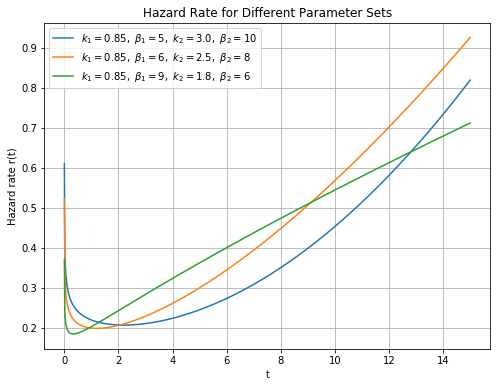

In [2]:
# Hazard function
def hazard(t, k1, beta1, k2, beta2):
    r1 = (k1 / beta1) * (t / beta1)**(k1 - 1)
    r2 = (k2 / beta2) * (t / beta2)**(k2 - 1)
    return r1 + r2

# Time grid 
t = np.linspace(0.001, 15, 1000)

# Parameter sets (k1, beta1, k2, beta2)
param_sets = [ 
    (0.85, 5, 3.0, 10),
    (0.85, 6, 2.5, 8),
    (0.85, 9, 1.8, 6), 
]

# Create figure
plt.figure(figsize=(8, 6))

for k1, beta1, k2, beta2 in param_sets:
    r = hazard(t, k1, beta1, k2, beta2)
    plt.plot(t, r, label=f"$k_1={k1},\\ \\beta_1={beta1},\\ k_2={k2},\\ \\beta_2={beta2}$"
)

plt.xlabel("t")
plt.ylabel("Hazard rate r(t)")
plt.title("Hazard Rate for Different Parameter Sets")
plt.legend()
plt.grid(True)

# Save figure
plt.savefig("hazard_plot.png", dpi=300, bbox_inches="tight")

# Show figure
plt.show()

We already know that the mean time to system failure is
$$
\mathcal{M}(\mathrm{T}) = \frac{1}{\lambda} \left(1 + \frac{(\lambda + \gamma_1)(\lambda + \gamma_2)}{ \lambda + \gamma_2 - \left(\gamma_2- \gamma_1\right) \overline{F}(\mathrm{T})  } \int_{0}^{\mathrm{T}} \overline{F}(t) \,\mathrm{d}t \right).
$$
When no PM is performed, the mean time to failure is then
$$
\mathcal{M}(\infty) = \frac{1}{\lambda} \left( 1+ a(\lambda + \gamma_1 ) \right).
$$

Since $\lim_{t\to\infty} r(t) = \infty$, the threshold time $\mathrm{T}_0$ and the optimal maintenance time $\mathrm{T}^*$ exist. Moreover, $\mathrm{T}_0$ is computed numerically as the unique solution to
$$
m(t) = \frac{a(\gamma_2 - \gamma_1)}{\lambda+\gamma_2},
$$
and $\mathrm{T}^*$ is the unique solution to
$$
r(t) \int_{0}^{t} \overline{F}(x) \mathrm{d}x + \overline{F}(t) = \frac{\lambda+\gamma_2}{\gamma_2 - \gamma_1}.
$$

We plot the difference $\mathcal{M}(\mathrm{T}) - \mathcal{M}(\infty)$.

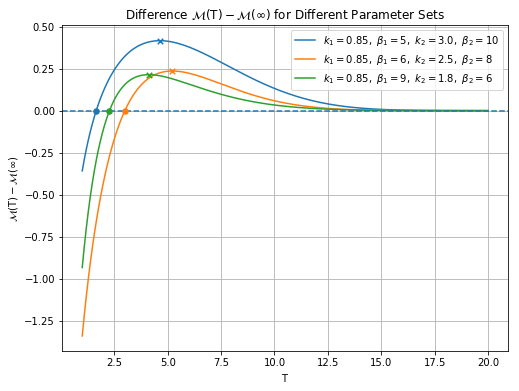

In [3]:
# Parameter sets
param_sets = [
    (5, 0.85, 10, 3.0, 0.001, 4, .1),
    (6, 0.85, 8, 2.5, 0.001, 4, 1.0),
    (9, 0.85, 6, 1.8, 0.001, 4, 1.0),
]

T_vals = np.linspace(1, 20, 200)

plt.figure(figsize=(8,6))

for i, (beta1, k1, beta2, k2, gamma1, gamma2, lam) in enumerate(param_sets):

    # Integrand
    def integrand(t):
        return np.exp(-(t/beta1)**k1 - (t/beta2)**k2)

    # Integral to infinity
    integral_inf, _ = quad(integrand, 0, np.inf)

    # M(T)
    def M_T(T):
        num, _ = quad(integrand, 0, T)
        denom = 1/(lam + gamma1) - ( 1/(lam+gamma1) - 1/(lam+gamma2) ) * np.exp(-(T/beta1)**k1 - (T/beta2)**k2)
        return (1/lam) * (1 + num / denom)

    # M(infty)
    M_inf = (1/lam) * (1 + integral_inf * (lam + gamma1))

    # Difference
    diff = lambda T: M_T(T) - M_inf
    diff_vals = np.array([diff(T) for T in T_vals])

    # K = a (gamma2 - gamma1) / (lambda + gamma2)
    K = integral_inf * (1-(lam + gamma1)/(lam+gamma2) )

    # Function m(t)
    def m(t, beta1, beta2, k1, k2):
        integral, _ = integrate.quad(integrand, t, np.inf, limit=200)
        denom = np.exp(- (t/beta1)**k1 - (t/beta2)**k2)
        return integral / denom

    # Solve m(t)=K
    def solve_t(K, beta1, beta2, k1, k2, t_min=0.1, t_max=20):
        f = lambda t: m(t, beta1, beta2, k1, k2) - K
        return brentq(f, t_min, t_max)

    T0 = solve_t(K, beta1, beta2, k1, k2)
    H0 = M_T(T0) - M_inf
    
    # T*
    def varphi(t, k1, beta1, k2, beta2):
        def hazard(t):
            r1 = (k1 / beta1) * (t / beta1)**(k1 - 1)
            r2 = (k2 / beta2) * (t / beta2)**(k2 - 1)    
            return r1 + r2
        def integ(t):
            integ_t, _ = quad(integrand, 0, t)
            return integ_t
        
        return hazard(t) * integ(t) + np.exp(- (t/beta1)**k1 - (t/beta2)**k2)
    
    # Solve varphi(t) = (lambda + gamma2) / (gamma2 - gamma1)
    mu1_Delta = 1/(1 - (lam + gamma1)/(lam + gamma2) ) 
    
    def solve_opt(mu1_Delta, beta1, beta2, k1, k2, t_min=0.1, t_max=20):
        f = lambda t: varphi(t, k1, beta1, k2, beta2) - mu1_Delta
        return brentq(f, t_min, t_max)


    T_opt = solve_opt(mu1_Delta, beta1, beta2, k1, k2)
    H_opt = M_T(T_opt) - M_inf
     
    # Plot
    line, = plt.plot(T_vals, diff_vals, label=f"$k_1={k1},\\ \\beta_1={beta1},\\ k_2={k2},\\ \\beta_2={beta2}$")
    color = line.get_color()
    
    plt.scatter(T0, H0, s=30, marker='o', zorder=5, color=color)
    plt.scatter(T_opt, H_opt, s=30, marker='x', zorder=5, color=color)

plt.axhline(0, linestyle="--")
plt.xlabel(r"$\mathrm{T}$")
plt.ylabel(r"$\mathcal{M}(\mathrm{T})-\mathcal{M}(\infty)$")
plt.title(r"Difference $\mathcal{M}(\mathrm{T})-\mathcal{M}(\infty)$ for Different Parameter Sets")
plt.legend()
plt.grid(True)
plt.savefig("M_difference_three_sets.png", dpi=300, bbox_inches="tight")
plt.show()

#### Remarks 
Figure above plots the difference $\mathcal{M}(\mathrm{T}) - \mathcal{M}(\infty)$. For the blue curve, $\mathrm{T}_0 < t_{\min} $, that means that the threshold lies in the interval where the hazard rate is decreasing. Graphically, it can be observed that the sharper the curvature of the hazard rate, the larger the values of both $\mathrm{T}_0$ and $\mathrm{T}^*$.